# ML Homework 5 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW5.ipynb" to "HW5_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together



** 6. Upload the saved 'Original vs Reconstructed Data' image files for both the worst and best models.

** 7. Upload the saved 'Latent Space Visualization (t-SNE)' image file for both the worst and best models.


# [HW 5] Grid Search for ConvAE and Visualization

1. Load your 'SoundSTFT.npy' file as you loaded in the 'ML10_Code1'.
2. Prepare training and test dataset with the test data ratio of """10%""".
3. Perform a grid search to find the best dimension of bottle neck layer for the ConvAE model.
  - You don't need to search other hyperparameters.

4. Determine your best and worst CNN model based on reconstruction error.
5. Compare original and reconstructed STFT spectrogram for both the worst and best models and save them as image files (.png or .jpg).
  - Upload the comparison images to BrightSpace with ipynb and pdf files

6. Extract latent space features from both the worst and best models and visualize them using t-SNE.
  - Save and upload the visualization results to BrightSpace as well.

In [3]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp
from scipy import signal

import librosa
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('librosa   :', librosa.__version__)

TensorFlow: 2.19.0
librosa   : 0.11.0


In [4]:
# Download the industrial sound recording
file_url = (
    'https://github.com/purduelamm/purdue_me597_iiot/blob/main/'
    'ml_tutorial/Dataset_IndustrialSound/Industrial_data_Stethoscope.wav?raw=true'
)
file_path = 'Industrial_data_Stethoscope.wav'
urllib.request.urlretrieve(file_url, file_path)

sound, rate = librosa.load(file_path, sr=None)
print(f'Sample rate : {rate} Hz')
print(f'Duration    : {len(sound)/rate:.2f} s  ({len(sound)} samples)')

Sample rate : 48000 Hz
Duration    : 142.46 s  (6837916 samples)


In [5]:
DATA_PATH = 'SoundSTFT.npy'

if not os.path.exists(DATA_PATH):
    print('SoundSTFT.npy not found — generating from sound/rate in memory ...')
    print(f'  Sample rate : {rate} Hz  |  Duration : {len(sound)/rate:.2f} s')

    # ── Class segmentation boundaries (from ML10_Code1) ──────────────────
    CLASS_NAMES_GEN = ['Tool Change', 'Chip Conveyer',
                       'Moving X', 'Moving Y', 'Moving Z', 'Spindle']
    timestamps  = [12.46, 32.51, 65.57, 95.30, 104.36, 112.12]
    indices     = np.multiply(rate, timestamps).astype(np.int64)
    NUM_CLASS   = len(CLASS_NAMES_GEN)

    raw_classes = []
    for i in range(NUM_CLASS):
        seg = sound[indices[i]:] if i == NUM_CLASS - 1 else sound[indices[i]:indices[i+1]]
        raw_classes.append(seg)

    # ── Fixed-length segmentation: 1 s window, 0.8 s overlap ─────────────
    SEGMENT_LEN = int(1.0 * rate)
    STEP        = int(0.2 * rate)   # 1.0 - 0.8 = 0.2 s

    def segmentation(data):
        segs, start = [], 0
        while start + SEGMENT_LEN <= len(data):
            segs.append(data[start: start + SEGMENT_LEN])
            start += STEP
        return np.array(segs, dtype=np.float32)

    segments_per_class = [segmentation(c) for c in raw_classes]

    # ── Compute STFT magnitude for every segment ──────────────────────────
    NPERSEG  = 78
    NOVERLAP = 10

    def compute_stft(segments):
        specs = []
        for seg in segments:
            _, _, Zxx = scipy_signal.spectrogram(
                seg, fs=rate, nperseg=NPERSEG, noverlap=NOVERLAP)
            specs.append(np.abs(Zxx).astype(np.float32))
        return np.array(specs)   # (N, freq_bins, time_frames)

    stft_per_class, label_per_class = [], []
    for cls_idx, segs in enumerate(segments_per_class):
        stft_segs = compute_stft(segs)
        stft_per_class.append(stft_segs)
        label_per_class.append(np.full(len(segs), cls_idx, dtype=np.int32))
        print(f'  Class {cls_idx+1} ({CLASS_NAMES_GEN[cls_idx]:16s}): '
              f'{stft_segs.shape[0]} segments  STFT shape {stft_segs.shape[1:]}')

    X_raw = np.concatenate(stft_per_class,  axis=0)   # (N, F, T)
    y_raw = np.concatenate(label_per_class, axis=0)   # (N,)

    # ── Save as SoundSTFT.npy ─────────────────────────────────────────────
    np.save(DATA_PATH, {'X': X_raw, 'y': y_raw})
    print(f'\n  Saved → {DATA_PATH}  '
          f'(X: {X_raw.shape}, y: {y_raw.shape})')
else:
    print(f'Found existing {DATA_PATH} — loading directly.')

# ── Step B: Load SoundSTFT.npy ────────────────────────────────────────────
raw = np.load(DATA_PATH, allow_pickle=True)
if isinstance(raw, np.ndarray) and raw.ndim == 0:
    raw = raw.item()  # unwrap object array wrapping a dict

if isinstance(raw, dict):
    X_all = raw['X'].astype(np.float32)   # (N, freq_bins, time_frames)
    y_all = np.array(raw['y'])            # (N,) integer class labels
else:
    X_all = raw.astype(np.float32)
    y_all = None
    print('WARNING: no labels in file — t-SNE colouring disabled')

print(f'\nLoaded STFT array shape : {X_all.shape}')
if y_all is not None:
    print(f'Labels shape            : {y_all.shape}')
    print(f'Class distribution      : {np.bincount(y_all)}')

# ── Step C: Normalise → resize to 32×32 → add channel dim ────────────────
TARGET_H, TARGET_W = 32, 32

def prepare_ae_input(stft_array, target_h=TARGET_H, target_w=TARGET_W):
    """log1p → per-sample min-max → resize to target_h×target_w → channel dim."""
    log_spec = np.log1p(stft_array)                          # (N, F, T)
    mn = log_spec.min(axis=(1, 2), keepdims=True)
    mx = log_spec.max(axis=(1, 2), keepdims=True)
    scaled = (log_spec - mn) / (mx - mn + 1e-8)             # [0, 1]
    imgs   = scaled[..., np.newaxis].astype(np.float32)      # (N, F, T, 1)
    resized = tf.image.resize(imgs, [target_h, target_w]).numpy()
    return resized  # (N, target_h, target_w, 1)

X_prepared = prepare_ae_input(X_all)   # (N, 32, 32, 1)
print(f'Prepared input shape    : {X_prepared.shape}')

# ── Step D: Train / Test split – 90 % train, 10 % test ───────────────────
TEST_RATIO   = 0.10
RANDOM_STATE = 42

if y_all is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_prepared, y_all,
        test_size    = TEST_RATIO,
        stratify     = y_all,
        random_state = RANDOM_STATE
    )
else:
    X_train, X_test = train_test_split(
        X_prepared,
        test_size    = TEST_RATIO,
        random_state = RANDOM_STATE
    )
    y_train = y_test = None

print(f'\nTrain set : {X_train.shape}')
print(f'Test  set : {X_test.shape}')

SoundSTFT.npy not found — generating from sound/rate in memory ...
  Sample rate : 48000 Hz  |  Duration : 142.46 s
  Class 1 (Tool Change     ): 96 segments  STFT shape (40, 705)
  Class 2 (Chip Conveyer   ): 161 segments  STFT shape (40, 705)
  Class 3 (Moving X        ): 144 segments  STFT shape (40, 705)
  Class 4 (Moving Y        ): 41 segments  STFT shape (40, 705)
  Class 5 (Moving Z        ): 34 segments  STFT shape (40, 705)
  Class 6 (Spindle         ): 147 segments  STFT shape (40, 705)

  Saved → SoundSTFT.npy  (X: (623, 40, 705), y: (623,))

Loaded STFT array shape : (623, 40, 705)
Labels shape            : (623,)
Class distribution      : [ 96 161 144  41  34 147]
Prepared input shape    : (623, 32, 32, 1)

Train set : (560, 32, 32, 1)
Test  set : (63, 32, 32, 1)


In [6]:
# ── Cell 2: Convolutional Autoencoder (ConvAE) Model Builder ──────────────
#
# Architecture overview
# ─────────────────────
# ENCODER
#   Input  (32, 32, 1)
#   Conv2D(32, 3×3, same) → ReLU → MaxPool(2×2)   →  (16, 16, 32)
#   Conv2D(64, 3×3, same) → ReLU → MaxPool(2×2)   →  ( 8,  8, 64)
#   Flatten                                         →  (4096,)
#   Dense(bottleneck_dim, ReLU)                     →  (bottleneck_dim,)  ← grid-search target
#
# DECODER
#   Dense(8*8*64, ReLU)                             →  (4096,)
#   Reshape                                         →  ( 8,  8, 64)
#   Conv2DTranspose(64, 3×3, same) → ReLU                →  ( 8,  8, 64)
#   UpSampling2D(2×2)                               →  (16, 16, 64)
#   Conv2DTranspose(32, 3×3, same) → ReLU                →  (16, 16, 32)
#   UpSampling2D(2×2)                               →  (32, 32, 32)
#   Conv2D(1, 3×3, same, sigmoid)                   →  (32, 32,  1)  ← reconstruction

def build_convae(input_shape=(32, 32, 1), bottleneck_dim=32):
    """Build a ConvAE with a variable-width bottleneck Dense layer.
    Returns (autoencoder, encoder) as a tuple.
    """
    # ── Encoder ──────────────────────────────────────────────────────────
    enc_input = keras.Input(shape=input_shape, name='encoder_input')

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(enc_input)
    x = layers.MaxPooling2D((2, 2))(x)        # → (16, 16, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)        # → ( 8,  8, 64)

    x = layers.Flatten()(x)                   # → (4096,)
    encoded = layers.Dense(bottleneck_dim, activation='relu',
                           name='bottleneck')(x)

    encoder = Model(enc_input, encoded, name=f'encoder_bn{bottleneck_dim}')

    # ── Decoder ──────────────────────────────────────────────────────────
    dec_input = keras.Input(shape=(bottleneck_dim,), name='decoder_input')

    x = layers.Dense(8 * 8 * 64, activation='relu')(dec_input)
    x = layers.Reshape((8, 8, 64))(x)

    x = layers.Conv2DTranspose(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.UpSampling2D((2, 2))(x)        # → (16, 16, 64)

    x = layers.Conv2DTranspose(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.UpSampling2D((2, 2))(x)        # → (32, 32, 32)

    decoded = layers.Conv2D(1, (3, 3), padding='same',
                            activation='sigmoid', name='decoder_output')(x)

    # ── Full autoencoder ─────────────────────────────────────────────────
    autoencoder = Model(enc_input, encoder(enc_input), name='bottleneck_only')
    # Wire encoder → decoder
    ae_output   = keras.Model(
        enc_input,
        keras.Model(dec_input, decoded)(encoder(enc_input)),
        name=f'convae_bn{bottleneck_dim}'
    )

    ae_output.compile(optimizer='adam', loss='mse')
    return ae_output, encoder


# Quick sanity-check with bottleneck_dim=16
_ae_test, _enc_test = build_convae(bottleneck_dim=16)
_ae_test.summary()
del _ae_test, _enc_test

Model: "convae_bn16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn16 (Functional)       │ (None, 16)             │        84,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 32, 32, 1)      │       125,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,681 (819.07 KB)

 Trainable params: 209,681 (819.07 KB)

 Non-trainable params: 0 (0.00 B)


=== Bottleneck dim =    4 ============================
  Stopped at epoch  10 | Test MSE = 0.000400

=== Bottleneck dim =    8 ============================
  Stopped at epoch  10 | Test MSE = 0.000400

=== Bottleneck dim =   16 ============================


  Stopped at epoch   9 | Test MSE = 0.000400

=== Bottleneck dim =   32 ============================
  Stopped at epoch   8 | Test MSE = 0.000524

=== Bottleneck dim =   64 ============================
  Stopped at epoch   9 | Test MSE = 0.000400

=== Bottleneck dim =  128 ============================
  Stopped at epoch   8 | Test MSE = 0.000400

── Grid Search Results (sorted by Test MSE) ──
 Bottleneck Dim  Test MSE  Epochs Trained
              4  0.000400              10
              8  0.000400              10
             16  0.000400               9
             64  0.000400               9
            128  0.000400               8
             32  0.000524               8


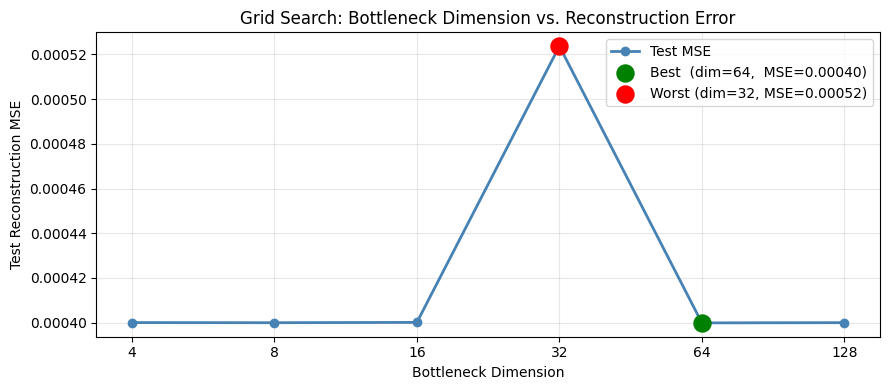


Best  model → bottleneck dim = 64  (Test MSE = 0.000400)
Worst model → bottleneck dim = 32 (Test MSE = 0.000524)


In [7]:
# ── Cell 3: Grid Search over Bottleneck Dimensions ────────────────────────
#
# We search the following bottleneck sizes and record:
#   • Training history (loss curves)
#   • Test reconstruction error (mean MSE over test set)
# The model with the LOWEST test MSE  → best model
# The model with the HIGHEST test MSE → worst model

BOTTLENECK_DIMS = [4, 8, 16, 32, 64, 128]   # grid search candidates
EPOCHS          = 50
BATCH_SIZE      = 32

grid_results = []   # list of dicts: {dim, model, encoder, history, test_mse}

early_stop = keras.callbacks.EarlyStopping(
    monitor  = 'val_loss',
    patience = 8,
    restore_best_weights = True
)

for bn_dim in BOTTLENECK_DIMS:
    print(f'\n=== Bottleneck dim = {bn_dim:4d} ============================')
    tf.keras.backend.clear_session()   # free GPU memory between runs
    tf.random.set_seed(42)

    ae_model, enc_model = build_convae(input_shape=(TARGET_H, TARGET_W, 1),
                                        bottleneck_dim=bn_dim)

    history = ae_model.fit(
        X_train, X_train,          # autoencoder: input == target
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_split= 0.10,    # 10 % of train for validation monitoring
        callbacks       = [early_stop],
        verbose         = 0
    )

    # ── Test reconstruction error ─────────────────────────────────────────
    X_recon   = ae_model.predict(X_test, verbose=0)
    test_mse  = float(np.mean((X_test - X_recon) ** 2))
    n_epochs  = len(history.history['loss'])

    print(f'  Stopped at epoch {n_epochs:3d} | Test MSE = {test_mse:.6f}')

    grid_results.append({
        'dim'      : bn_dim,
        'model'    : ae_model,
        'encoder'  : enc_model,
        'history'  : history,
        'test_mse' : test_mse,
        'n_epochs' : n_epochs
    })

# ── Summary table ─────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {'Bottleneck Dim': r['dim'],
     'Test MSE'     : round(r['test_mse'], 6),
     'Epochs Trained': r['n_epochs']}
    for r in grid_results
]).sort_values('Test MSE')

print('\n── Grid Search Results (sorted by Test MSE) ──')
print(summary_df.to_string(index=False))

# ── Plot reconstruction error vs bottleneck dimension ─────────────────────
dims = [r['dim']      for r in grid_results]
mses = [r['test_mse'] for r in grid_results]

best_idx  = int(np.argmin(mses))
worst_idx = int(np.argmax(mses))

plt.figure(figsize=(9, 4))
plt.plot(dims, mses, marker='o', linewidth=2, color='steelblue', label='Test MSE')
plt.scatter([dims[best_idx]],  [mses[best_idx]],  s=150, zorder=5,
            color='green',  label=f'Best  (dim={dims[best_idx]},  MSE={mses[best_idx]:.5f})')
plt.scatter([dims[worst_idx]], [mses[worst_idx]], s=150, zorder=5,
            color='red',    label=f'Worst (dim={dims[worst_idx]}, MSE={mses[worst_idx]:.5f})')
plt.xlabel('Bottleneck Dimension')
plt.ylabel('Test Reconstruction MSE')
plt.title('Grid Search: Bottleneck Dimension vs. Reconstruction Error')
plt.xscale('log', base=2)
plt.xticks(dims, dims)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nBest  model → bottleneck dim = {dims[best_idx]}  (Test MSE = {mses[best_idx]:.6f})')
print(f'Worst model → bottleneck dim = {dims[worst_idx]} (Test MSE = {mses[worst_idx]:.6f})')

── Best Model ──────────────────────────────────────────────────────
Saved → Original_vs_Reconstructed_BEST.png


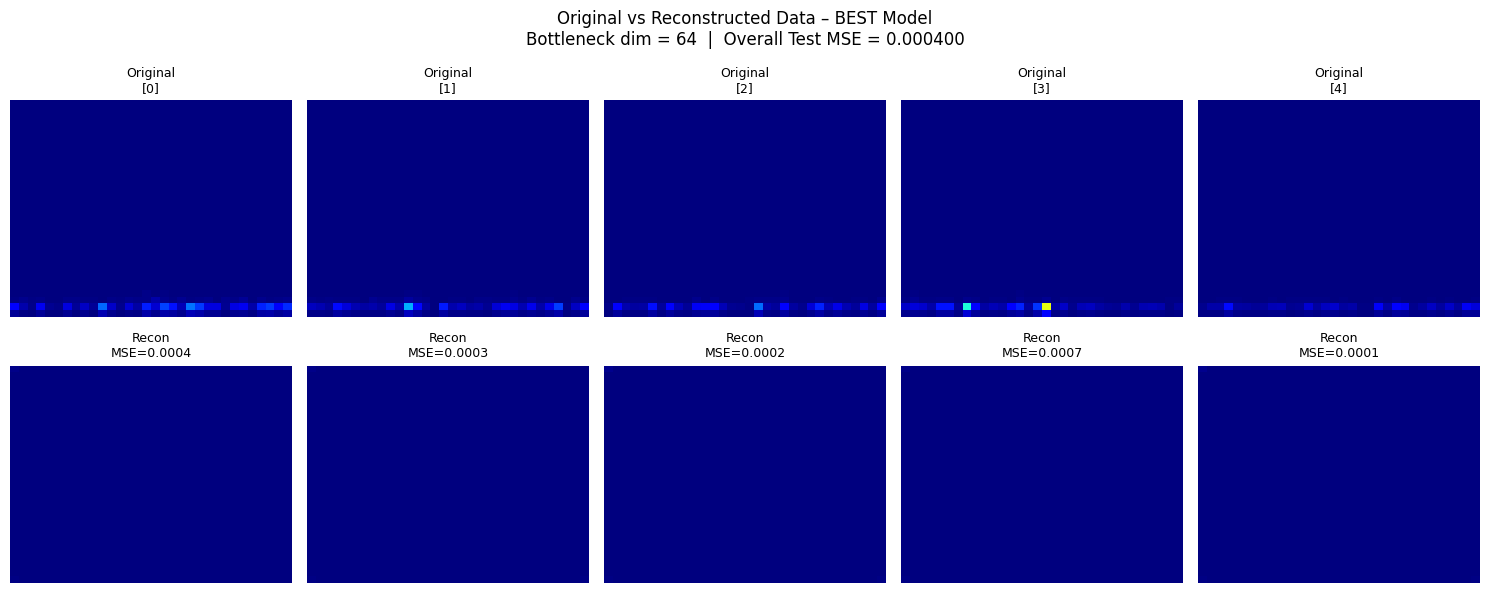

── Worst Model ─────────────────────────────────────────────────────
Saved → Original_vs_Reconstructed_WORST.png


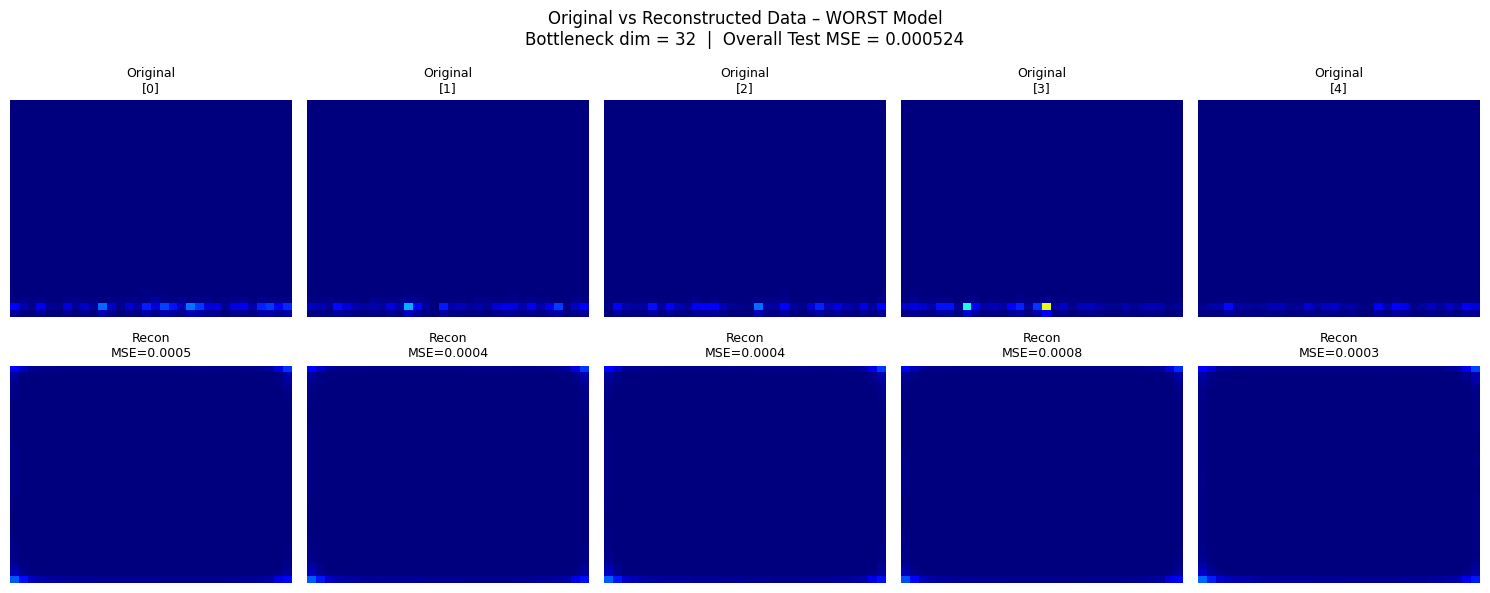

In [8]:
# ── Cell 4: Original vs. Reconstructed STFT Comparison & Save Images ──────

best_result  = grid_results[best_idx]
worst_result = grid_results[worst_idx]

N_SHOW = 5   # number of test samples to compare side-by-side

def plot_reconstruction(ae_model, X_test_data, bn_dim, label,
                        n_show=N_SHOW, save_path=None):
    """Plot original vs reconstructed STFT spectrograms for n_show samples."""
    X_recon = ae_model.predict(X_test_data[:n_show], verbose=0)  # (n, 32, 32, 1)
    mse_per_sample = np.mean((X_test_data[:n_show] - X_recon) ** 2, axis=(1, 2, 3))

    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

    for i in range(n_show):
        axes[0, i].imshow(X_test_data[i, :, :, 0], cmap='jet',
                          aspect='auto', origin='lower', vmin=0, vmax=1)
        axes[0, i].set_title(f'Original\n[{i}]', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(X_recon[i, :, :, 0], cmap='jet',
                          aspect='auto', origin='lower', vmin=0, vmax=1)
        axes[1, i].set_title(f'Recon\nMSE={mse_per_sample[i]:.4f}', fontsize=9)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original',      fontsize=11, rotation=90, labelpad=40)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=11, rotation=90, labelpad=40)

    overall_mse = np.mean((X_test_data - ae_model.predict(X_test_data, verbose=0)) ** 2)
    fig.suptitle(
        f'Original vs Reconstructed Data – {label}\n'
        f'Bottleneck dim = {bn_dim}  |  Overall Test MSE = {overall_mse:.6f}',
        fontsize=12
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


# ── Best model comparison ─────────────────────────────────────────────────
print('── Best Model ──────────────────────────────────────────────────────')
plot_reconstruction(
    ae_model   = best_result['model'],
    X_test_data= X_test,
    bn_dim     = best_result['dim'],
    label      = 'BEST Model',
    save_path  = 'Original_vs_Reconstructed_BEST.png'
)

# ── Worst model comparison ────────────────────────────────────────────────
print('── Worst Model ─────────────────────────────────────────────────────')
plot_reconstruction(
    ae_model   = worst_result['model'],
    X_test_data= X_test,
    bn_dim     = worst_result['dim'],
    label      = 'WORST Model',
    save_path  = 'Original_vs_Reconstructed_WORST.png'
)

── Best Model t-SNE ────────────────────────────────────────────────
Latent feature shape (BEST Model): (623, 64)
Saved → Latent_Space_tSNE_BEST.png


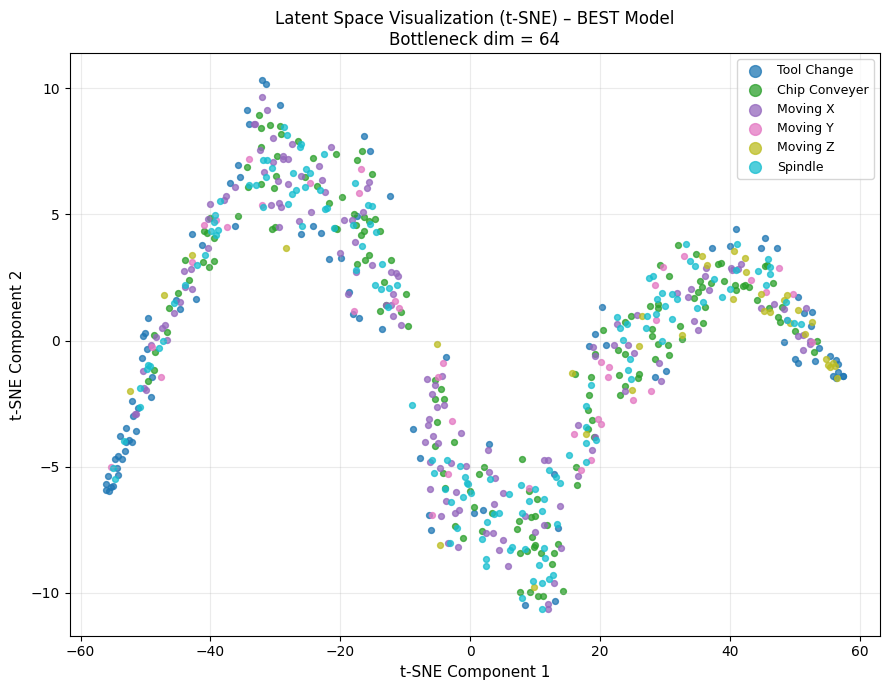

── Worst Model t-SNE ───────────────────────────────────────────────
Latent feature shape (WORST Model): (623, 32)
Saved → Latent_Space_tSNE_WORST.png


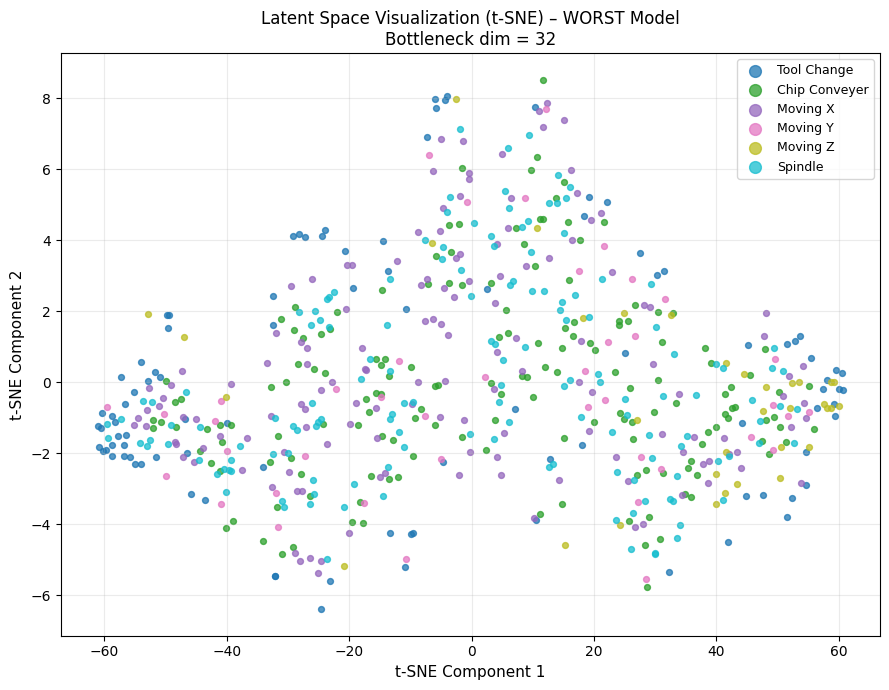

In [9]:
# ── Cell 5: Latent Space Extraction & t-SNE Visualisation ─────────────────

CLASS_NAMES = ['Tool Change', 'Chip Conveyer',
               'Moving X', 'Moving Y', 'Moving Z', 'Spindle']
cmap_tsne   = plt.cm.get_cmap('tab10', len(CLASS_NAMES))

def visualize_latent_tsne(encoder_model, X_data, y_labels,
                           bn_dim, model_label, save_path=None):
    """Extract latent vectors, run t-SNE, and plot a 2-D scatter."""
    # Extract bottleneck features
    latent_features = encoder_model.predict(X_data, verbose=0)  # (N, bn_dim)
    print(f'Latent feature shape ({model_label}): {latent_features.shape}')

    # t-SNE reduction to 2-D
    perplexity = min(30, latent_features.shape[0] - 1)  # guard small datasets
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, n_iter=1000)
    Z = tsne.fit_transform(latent_features)  # (N, 2)

    fig, ax = plt.subplots(figsize=(9, 7))

    if y_labels is not None:
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mask = (y_labels == cls_idx)
            if mask.sum() == 0:
                continue
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       s=18, alpha=0.75,
                       color=cmap_tsne(cls_idx),
                       label=cls_name)
        ax.legend(fontsize=9, markerscale=2, loc='best')
    else:
        ax.scatter(Z[:, 0], Z[:, 1], s=18, alpha=0.6)

    ax.set_xlabel('t-SNE Component 1', fontsize=11)
    ax.set_ylabel('t-SNE Component 2', fontsize=11)
    ax.set_title(
        f'Latent Space Visualization (t-SNE) – {model_label}\n'
        f'Bottleneck dim = {bn_dim}',
        fontsize=12
    )
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


# Use the FULL prepared dataset for a richer t-SNE (more points = better structure)
X_all_tsne = X_prepared
y_all_tsne = y_all

# ── Best model t-SNE ──────────────────────────────────────────────────────
print('── Best Model t-SNE ────────────────────────────────────────────────')
visualize_latent_tsne(
    encoder_model = best_result['encoder'],
    X_data        = X_all_tsne,
    y_labels      = y_all_tsne,
    bn_dim        = best_result['dim'],
    model_label   = 'BEST Model',
    save_path     = 'Latent_Space_tSNE_BEST.png'
)

# ── Worst model t-SNE ─────────────────────────────────────────────────────
print('── Worst Model t-SNE ───────────────────────────────────────────────')
visualize_latent_tsne(
    encoder_model = worst_result['encoder'],
    X_data        = X_all_tsne,
    y_labels      = y_all_tsne,
    bn_dim        = worst_result['dim'],
    model_label   = 'WORST Model',
    save_path     = 'Latent_Space_tSNE_WORST.png'
)

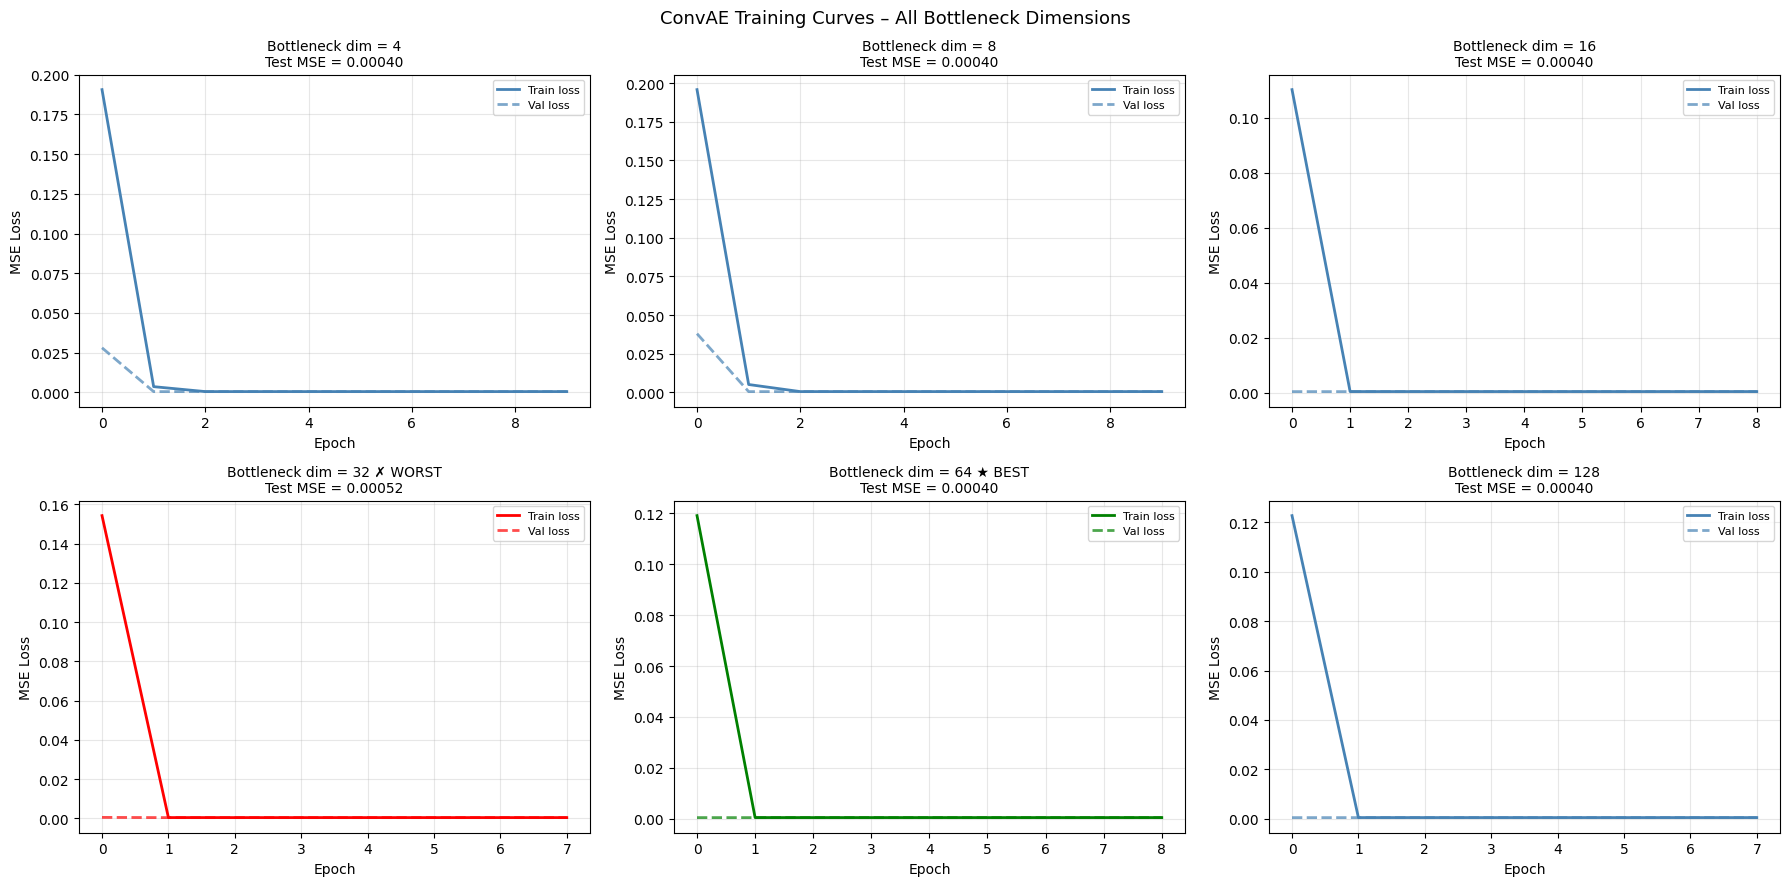

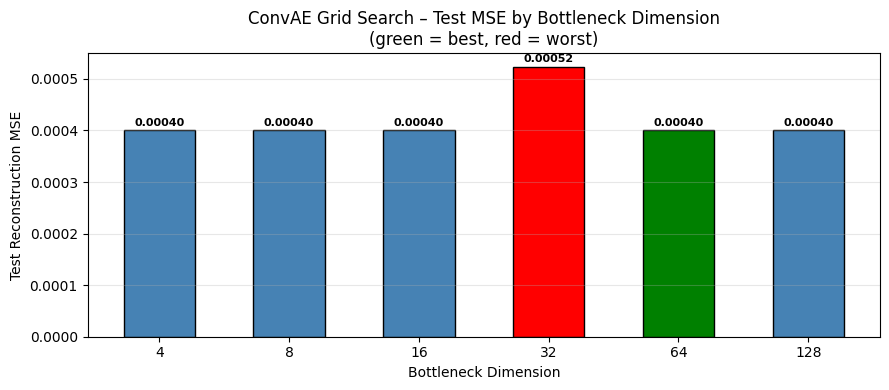


════════════════════ GRID SEARCH SUMMARY ═══════════════════════
 Bottleneck Dim  Test MSE  Epochs Trained
              4  0.000400              10
              8  0.000400              10
             16  0.000400               9
             64  0.000400               9
            128  0.000400               8
             32  0.000524               8

  Best  model : bottleneck dim =   64  |  Test MSE = 0.000400
  Worst model : bottleneck dim =   32  |  Test MSE = 0.000524

Saved images:
  • Original_vs_Reconstructed_BEST.png
  • Original_vs_Reconstructed_WORST.png
  • Latent_Space_tSNE_BEST.png
  • Latent_Space_tSNE_WORST.png
══════════════════════════════════════════════════════════════════


In [10]:
# ── Cell 6: Training Curves & Final Summary ────────────────────────────────

# ── Plot training loss curves for all bottleneck sizes ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, res in zip(axes, grid_results):
    bn_dim = res['dim']
    hist   = res['history'].history
    color  = 'green' if res is best_result else ('red' if res is worst_result else 'steelblue')

    ax.plot(hist['loss'],     label='Train loss', linewidth=2, color=color)
    ax.plot(hist['val_loss'], label='Val loss',   linewidth=2,
            color=color, linestyle='--', alpha=0.7)
    tag = ' ★ BEST' if res is best_result else (' ✗ WORST' if res is worst_result else '')
    ax.set_title(f'Bottleneck dim = {bn_dim}{tag}\nTest MSE = {res["test_mse"]:.5f}',
                 fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('ConvAE Training Curves – All Bottleneck Dimensions', fontsize=13)
plt.tight_layout(); plt.show()

# ── Bar chart: test MSE per bottleneck size ───────────────────────────────
bar_colors = [
    'green' if i == best_idx else
    ('red'  if i == worst_idx else 'steelblue')
    for i in range(len(grid_results))
]

plt.figure(figsize=(9, 4))
bars = plt.bar([str(r['dim']) for r in grid_results],
               [r['test_mse'] for r in grid_results],
               color=bar_colors, edgecolor='k', width=0.55)
for bar, res in zip(bars, grid_results):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5e-6,
             f"{res['test_mse']:.5f}",
             ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.xlabel('Bottleneck Dimension')
plt.ylabel('Test Reconstruction MSE')
plt.title('ConvAE Grid Search – Test MSE by Bottleneck Dimension\n'
          '(green = best, red = worst)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── Final console summary ─────────────────────────────────────────────────
print('\n════════════════════ GRID SEARCH SUMMARY ═══════════════════════')
print(summary_df.to_string(index=False))
print(f'\n  Best  model : bottleneck dim = {best_result["dim"]:4d}'
      f'  |  Test MSE = {best_result["test_mse"]:.6f}')
print(f'  Worst model : bottleneck dim = {worst_result["dim"]:4d}'
      f'  |  Test MSE = {worst_result["test_mse"]:.6f}')
print('\nSaved images:')
print('  • Original_vs_Reconstructed_BEST.png')
print('  • Original_vs_Reconstructed_WORST.png')
print('  • Latent_Space_tSNE_BEST.png')
print('  • Latent_Space_tSNE_WORST.png')
print('══════════════════════════════════════════════════════════════════')

## ML7 and ML8 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML7 and ML8.

---

Write down A1 here.


HW5 involves building a Convolutional Autoencoder (ConvAE) on industrial sound STFT spectrograms across 6 machine operation classes. You generate the data from a raw audio recording, split it 90/10 into train/test, then run a grid search over different bottleneck dimensions (4, 8, 16, 32, 64, 128) to find which size gives the best and worst reconstruction error (MSE). For both the best and worst models, you save side-by-side plots of original vs. reconstructed spectrograms, and also extract the bottleneck features and visualize them using t-SNE to see how well the latent space separates the 6 classes.


---

### Q2. What skills did you have to develop to accomplish this project?

---

Wirte down A2 here.



To complete this project, you needed to understand how to compute and preprocess STFT spectrograms from raw audio signals, design a convolutional autoencoder architecture with an encoder-decoder structure, and implement a grid search to systematically compare models. You also had to work with TensorFlow/Keras to build and train deep learning models, use t-SNE for dimensionality reduction and latent space visualization, and manage the full ML pipeline from raw data ingestion through evaluation and figure export.
---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Wirte down A3 here.


The most valuable learning came from understanding how autoencoders learn compressed representations — seeing concretely how bottleneck size controls the trade-off between compression and reconstruction quality. The t-SNE visualization was especially insightful because it made the abstract concept of a latent space tangible, showing whether the model had learned features that meaningfully separate different machine states even without any class labels during training. The grid search also reinforced good experimental habits around comparing models fairly using a held-out test set.
---

### Q4. What challenges did you encounter in completing the project?

---

Wirte down A4 here.

NA

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Wirte down A5 here.


NA
---